# 08 — Comparative Modeling: Albania vs. Peers (PISA 2022)

Are Albania's risk drivers universal or idiosyncratic, and is its socioeconomic gradient unusual? We fit the **school-context LightGBM per country** (nine countries), score weighted 5-fold CV AUC, assemble a **SHAP importance rank matrix** (feature × country), and measure each country's **SES gradient** (weighted slope of math score on ESCS). Heavy fitting lives in `scripts/run_comparative_modeling.py`; this notebook loads its results and narrates.

## Methods & formulas (reference)

**Per-country models.** One school-context LightGBM per country, scored by weighted
5-fold CV AUC (notebook 04 metrics). Per-country AUCs are **not** directly
comparable as "model quality": separability is hardest near a saturated base rate
(when $\approx\!3/4$ are at-risk there is little contrast), so AUC partly reflects
prevalence.

**SHAP rank matrix.** Within each country, features are ranked by mean $|\phi_i|$
(notebook 05); rank 1 = top driver. The feature $\times$ country matrix exposes
**universal** drivers (similar rank everywhere) vs **country-specific** ones. The
colormap follows the project schema — **dark = more important** (colorblind-safe),
rank 1 darkest.

**SES gradient** = weighted slope of score on ESCS (notebook 02); Albania's is the
*flattest* — a floor effect, not equity.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
tbl = pd.read_csv('../outputs/results/comparative_country_2022.csv')
tbl

,country,group,n,at_risk_rate,cv_auc,cv_auc_std,ses_gradient
0,ALB,Albania,6129,0.7536,0.7728,0.0234,16.68
1,MKD,Balkan,6610,0.6605,0.8347,0.0108,31.43
2,MNE,Balkan,5793,0.5980,0.8189,0.0089,29.26
3,SRB,Balkan,6413,0.4349,0.8027,0.0196,38.91
4,BGR,Balkan,6107,0.5358,0.8566,0.0061,38.27
5,COL,GDP-matched,7804,0.6846,0.8618,0.0069,24.55
6,MEX,GDP-matched,6288,0.6686,0.7930,0.0117,19.24
7,EST,Top performer,6392,0.1253,0.7529,0.0132,39.40
8,FIN,Top performer,10239,0.2868,0.7883,0.0118,38.48


## 1. Predictability, prevalence, and the SES gradient

Three numbers per country: how often students are at-risk, how well the model separates them (CV AUC), and how steeply score tracks SES.

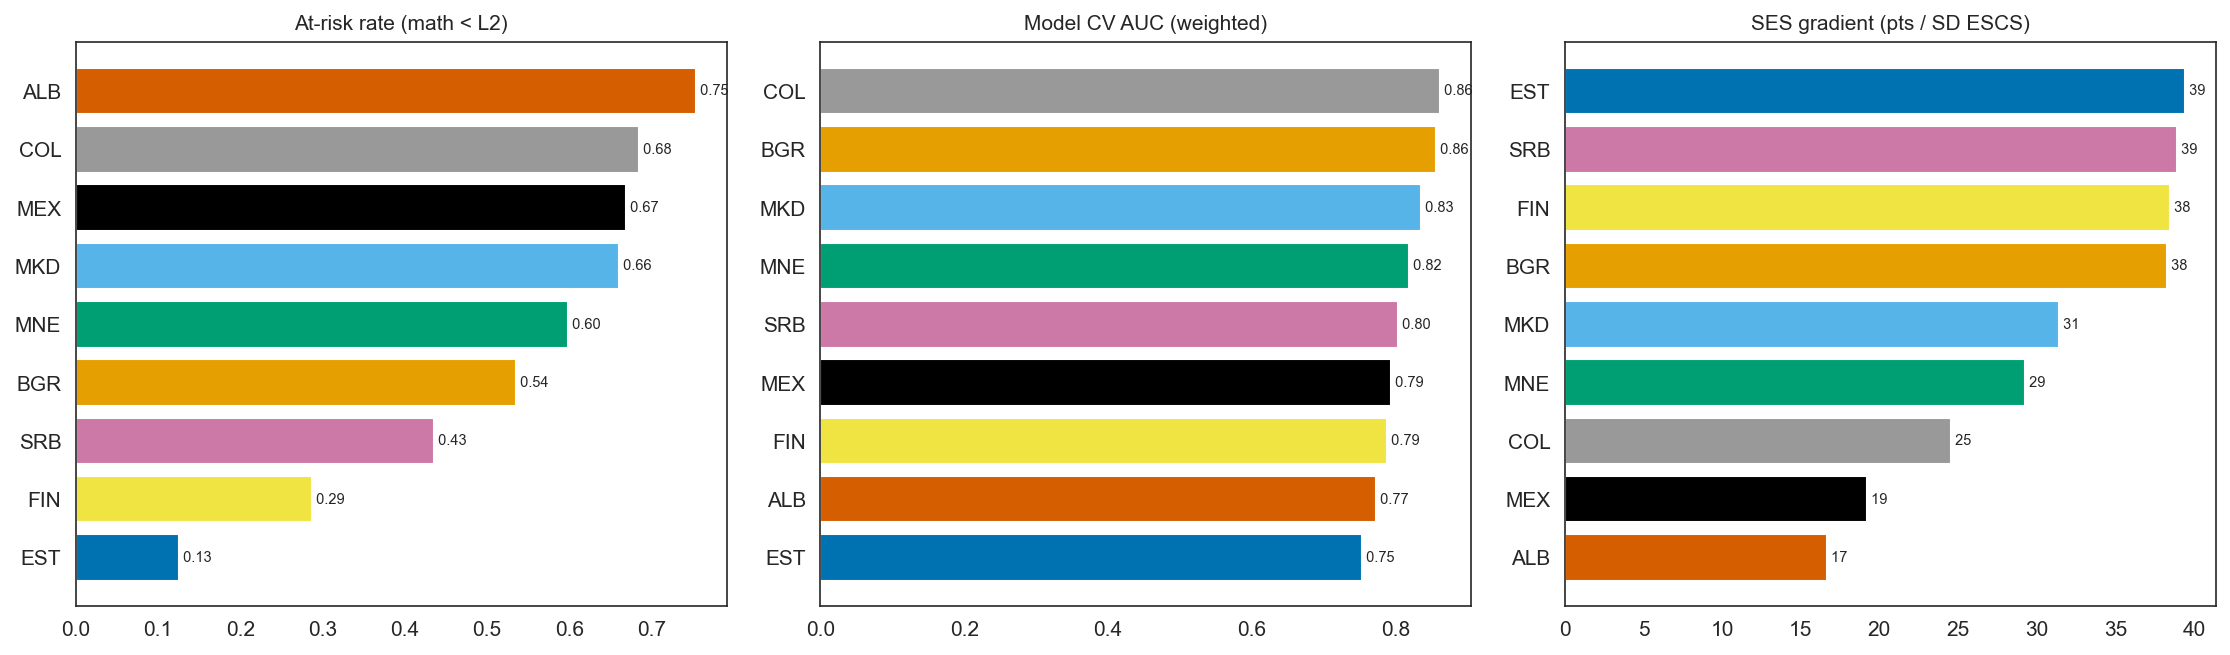

In [3]:
from src.visualization.style import apply_publication_style, COUNTRY_COLORS
apply_publication_style()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = [COUNTRY_COLORS.get(c, '#888') for c in tbl['country']]
for ax, col, title in zip(axes,
        ['at_risk_rate','cv_auc','ses_gradient'],
        ['At-risk rate (math < L2)','Model CV AUC (weighted)','SES gradient (pts / SD ESCS)']):
    order = tbl.sort_values(col)
    ax.barh(order['country'], order[col],
            color=[COUNTRY_COLORS.get(c,'#888') for c in order['country']])
    ax.set_title(title, fontsize=10)
    for i,(c,v) in enumerate(zip(order['country'], order[col])):
        ax.text(v, i, f' {v:.2f}' if col!='ses_gradient' else f' {v:.0f}', va='center', fontsize=7)
plt.tight_layout(); plt.show()

**Reading:** Albania has the **highest at-risk rate (0.75)** yet is among the **hardest to predict (AUC 0.77)** — when three of four students are at-risk there is little contrast to separate. Crucially, Albania's **SES gradient is the *flattest* (~17 pts/SD)** of all nine countries. That is a *floor effect*, not equity: even advantaged Albanian students score low (mean ~369), so SES barely predicts within-country. Estonia/Finland show *steeper* gradients (~38–40) but far higher levels. The mid-prevalence Balkan peers (BGR/COL, AUC ~0.86) are the most separable.

## 2. SHAP importance rank matrix

For each country, features ranked 1 (top driver) … by mean |SHAP|. Following the project's colormap schema (**dark = more important**; the colorblind-unsafe red-yellow-green map is avoided), rank 1 renders darkest. Which drivers are universal, which country-specific?

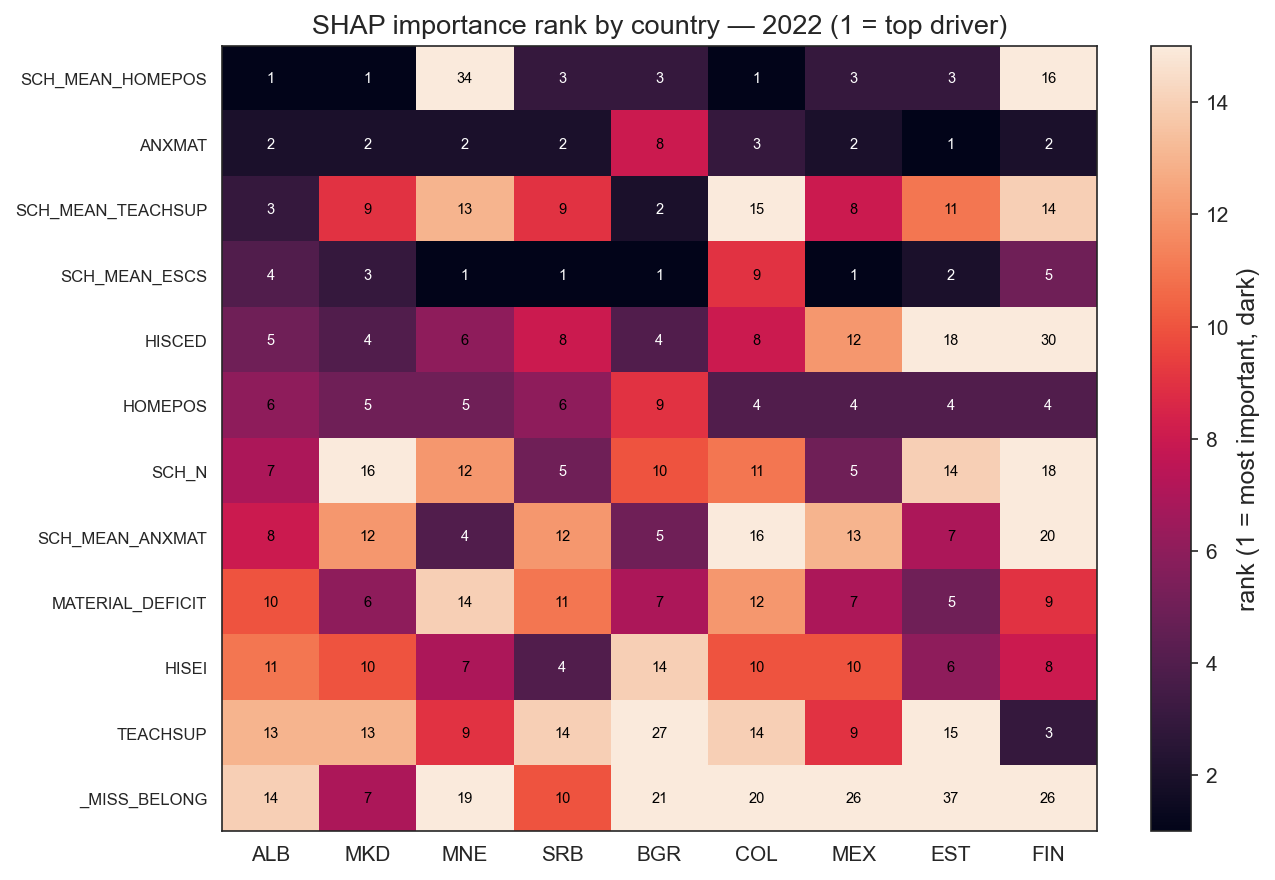

In [4]:
from src.visualization.style import SEQUENTIAL_RANK_CMAP
rank = pd.read_csv('../outputs/results/comparative_shap_rank_matrix.csv', index_col=0)
rank = rank.head(12)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(rank.values, cmap=SEQUENTIAL_RANK_CMAP, aspect='auto', vmin=1, vmax=15)
ax.set_xticks(range(len(rank.columns))); ax.set_xticklabels(rank.columns)
ax.set_yticks(range(len(rank.index))); ax.set_yticklabels(rank.index, fontsize=8)
for i in range(len(rank.index)):
    for j in range(len(rank.columns)):
        v = int(rank.values[i,j])
        ax.text(j, i, v, ha='center', va='center', fontsize=7,
                color='white' if v <= 5 else 'black')
ax.set_title('SHAP importance rank by country — 2022 (1 = top driver)')
fig.colorbar(im, ax=ax, label='rank (1 = most important, dark)'); plt.tight_layout(); plt.show()

**Reading:** **math anxiety (`ANXMAT`) is universal** — a top-3 driver in almost every country, including top-performer Estonia. **School composition** (`SCH_MEAN_HOMEPOS`, `SCH_MEAN_ESCS`) leads in most systems too. Albania's profile (school-HOMEPOS → anxiety → school-TEACHSUP → school-ESCS) is therefore **not idiosyncratic** — it shares the region's structure. Country-specific notes: grade repetition (`GRADE`) jumps to #2 in Colombia; individual `ESCS` is #1 in Finland (stronger individual-SES determinism).

## Conclusions & Interpretation

- **Albania = high prevalence, low separability, flat gradient.** Highest at-risk share (75%), one of the lowest model AUCs (0.77), and the flattest SES gradient (~17 pts/SD). The 2022 crisis is **broad-based** — depressed across the whole SES distribution, not concentrated in the poor.
- **Drivers are shared, not unique.** Math anxiety is a universal top factor and school socioeconomic composition dominates almost everywhere; Albania's risk structure mirrors its Balkan peers rather than standing apart. What sets Albania apart is the *level* and *breadth* of low proficiency, not a different mechanism.
- **Policy read.** Because the gradient is flat and school composition dominates, SES-targeted transfers alone would miss most of Albania's at-risk students; system-wide levers (teacher support, math-anxiety reduction, raising the floor across all schools) are needed. Estonia's steep-but-high profile shows the opposite regime — a useful contrast, not a template to copy directly.
- **Caveat.** Per-country AUCs are not directly comparable as 'model quality' — they partly reflect each country's at-risk prevalence (separability is hardest near 0/1 base rates). SHAP explains each *model*, associational not causal. Fits are single all-data LightGBM per country; figure `F1_shap_rank_matrix`.